# 01 — Chargement & Nettoyage des données

> **Objectif** : charger le CSV brut, parser les colonnes complexes, extraire les statistiques et sauvegarder un DataFrame propre pour les notebooks suivants.


In [13]:
import pandas as pd
import numpy as np
import ast
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F5F6FA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
})

STATS = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']
STAT_LABELS = {
    'hp': 'HP', 'attack': 'Attaque', 'defense': 'Défense',
    'special-attack': 'Att. Spé.', 'special-defense': 'Déf. Spé.', 'speed': 'Vitesse'
}
TYPE_COLORS = {
    'normal': '#A8A878', 'fire': '#F08030', 'water': '#6890F0', 'electric': '#F8D030',
    'grass': '#78C850', 'ice': '#98D8D8', 'fighting': '#C03028', 'poison': '#A040A0',
    'ground': '#E0C068', 'flying': '#A890F0', 'psychic': '#F85888', 'bug': '#A8B820',
    'rock': '#B8A038', 'ghost': '#705898', 'dragon': '#7038F8', 'dark': '#705848',
    'steel': '#B8B8D0', 'fairy': '#EE99AC', 'stellar': '#40B5A5',
}
print('Librairies chargées')

Librairies chargées


## 1. Chargement du CSV brut


In [14]:
df = pd.read_csv('../data/pokemon_data.csv')
print(f'Shape brut : {df.shape}')
print(f'Colonnes   : {list(df.columns)}')
df.head(10)

Shape brut : (1025, 8)
Colonnes   : ['id', 'name', 'types', 'abilities', 'moves', 'stats', 'game_indices', 'generation']


,id,name,types,abilities,moves,stats,game_indices,generation
0,1,bulbasaur,"['grass', 'poison']","['overgrow', 'chlorophyll']","['razor-wind', 'swords-dance', 'cut', 'bind', ...","{'hp': 45, 'attack': 49, 'defense': 49, 'speci...","['red', 'blue', 'yellow', 'gold', 'silver', 'c...",generation-i
1,2,ivysaur,"['grass', 'poison']","['overgrow', 'chlorophyll']","['swords-dance', 'cut', 'bind', 'vine-whip', '...","{'hp': 60, 'attack': 62, 'defense': 63, 'speci...","['red', 'blue', 'yellow', 'gold', 'silver', 'c...",generation-i
2,3,venusaur,"['grass', 'poison']","['overgrow', 'chlorophyll']","['swords-dance', 'cut', 'bind', 'vine-whip', '...","{'hp': 80, 'attack': 82, 'defense': 83, 'speci...","['red', 'blue', 'yellow', 'gold', 'silver', 'c...",generation-i
3,4,charmander,['fire'],"['blaze', 'solar-power']","['mega-punch', 'fire-punch', 'thunder-punch', ...","{'hp': 39, 'attack': 52, 'defense': 43, 'speci...","['red', 'blue', 'yellow', 'gold', 'silver', 'c...",generation-i
4,5,charmeleon,['fire'],"['blaze', 'solar-power']","['mega-punch', 'fire-punch', 'thunder-punch', ...","{'hp': 58, 'attack': 64, 'defense': 58, 'speci...","['red', 'blue', 'yellow', 'gold', 'silver', 'c...",generation-i
5,6,charizard,"['fire', 'flying']","['blaze', 'solar-power']","['mega-punch', 'fire-punch', 'thunder-punch', ...","{'hp': 78, 'attack': 84, 'defense': 78, 'speci...","['red', 'blue', 'yellow', 'gold', 'silver', 'c...",generation-i
6,7,squirtle,['water'],"['torrent', 'rain-dish']","['mega-punch', 'ice-punch', 'mega-kick', 'head...","{'hp': 44, 'attack': 48, 'defense': 65, 'speci...","['red', 'blue', 'yellow', 'gold', 'silver', 'c...",generation-i
7,8,wartortle,['water'],"['torrent', 'rain-dish']","['mega-punch', 'ice-punch', 'mega-kick', 'head...","{'hp': 59, 'attack': 63, 'defense': 80, 'speci...","['red', 'blue', 'yellow', 'gold', 'silver', 'c...",generation-i
8,9,blastoise,['water'],"['torrent', 'rain-dish']","['mega-punch', 'ice-punch', 'mega-kick', 'head...","{'hp': 79, 'attack': 83, 'defense': 100, 'spec...","['red', 'blue', 'yellow', 'gold', 'silver', 'c...",generation-i
9,10,caterpie,['bug'],"['shield-dust', 'run-away']","['tackle', 'string-shot', 'snore', 'bug-bite',...","{'hp': 45, 'attack': 30, 'defense': 35, 'speci...","['red', 'blue', 'yellow', 'gold', 'silver', 'c...",generation-i


## 2. Parsing des colonnes liste


In [15]:
for col in ['types', 'abilities', 'moves', 'game_indices', 'stats']:
    df[col] = df[col].apply(ast.literal_eval)

for stat in STATS:
    df[stat] = df['stats'].apply(lambda s: s.get(stat, np.nan))

df['bst']     = df[STATS].sum(axis=1)
df['type1']   = df['types'].apply(lambda t: t[0] if len(t) > 0 else None)
df['type2']   = df['types'].apply(lambda t: t[1] if len(t) > 1 else None)
df['n_types'] = df['types'].apply(len)
df['n_moves'] = df['moves'].apply(len)
df['n_games'] = df['game_indices'].apply(len)

print('Parsing terminé')

Parsing terminé


## 3. Nettoyage


In [16]:
n_before = len(df)
df.drop_duplicates(subset='id', inplace=True)
df.dropna(subset=['name', 'type1'] + STATS, inplace=True)
df.reset_index(drop=True, inplace=True)
n_after = len(df)

print(f'Lignes avant nettoyage : {n_before}')
print(f'Lignes après nettoyage  : {n_after}')
print(f'Supprimées              : {n_before - n_after}')
print(f'Valeurs manquantes :')
display(df[STATS + ['bst', 'type1']].isnull().sum().rename('NaN count').to_frame())

Lignes avant nettoyage : 1025
Lignes après nettoyage  : 1025
Supprimées              : 0
Valeurs manquantes :


,NaN count
hp,0
attack,0
defense,0
special-attack,0
special-defense,0
speed,0
bst,0
type1,0


## 4. Aperçu du DataFrame nettoyé


,id,name,generation,type1,type2,n_types,hp,attack,defense,special-attack,special-defense,speed,bst,n_moves
0,1,bulbasaur,generation-i,grass,poison,2,45,49,49,65,65,45,318,86
1,2,ivysaur,generation-i,grass,poison,2,60,62,63,80,80,60,405,83
2,3,venusaur,generation-i,grass,poison,2,80,82,83,100,100,80,525,96
3,4,charmander,generation-i,fire,NaN,1,39,52,43,60,50,65,309,105
4,5,charmeleon,generation-i,fire,NaN,1,58,64,58,80,65,80,405,103
5,6,charizard,generation-i,fire,flying,2,78,84,78,109,85,100,534,131
6,7,squirtle,generation-i,water,NaN,1,44,48,65,50,64,43,314,105
7,8,wartortle,generation-i,water,NaN,1,59,63,80,65,80,58,405,101
8,9,blastoise,generation-i,water,NaN,1,79,83,100,85,105,78,530,120
9,10,caterpie,generation-i,bug,NaN,1,45,30,35,20,20,45,195,5


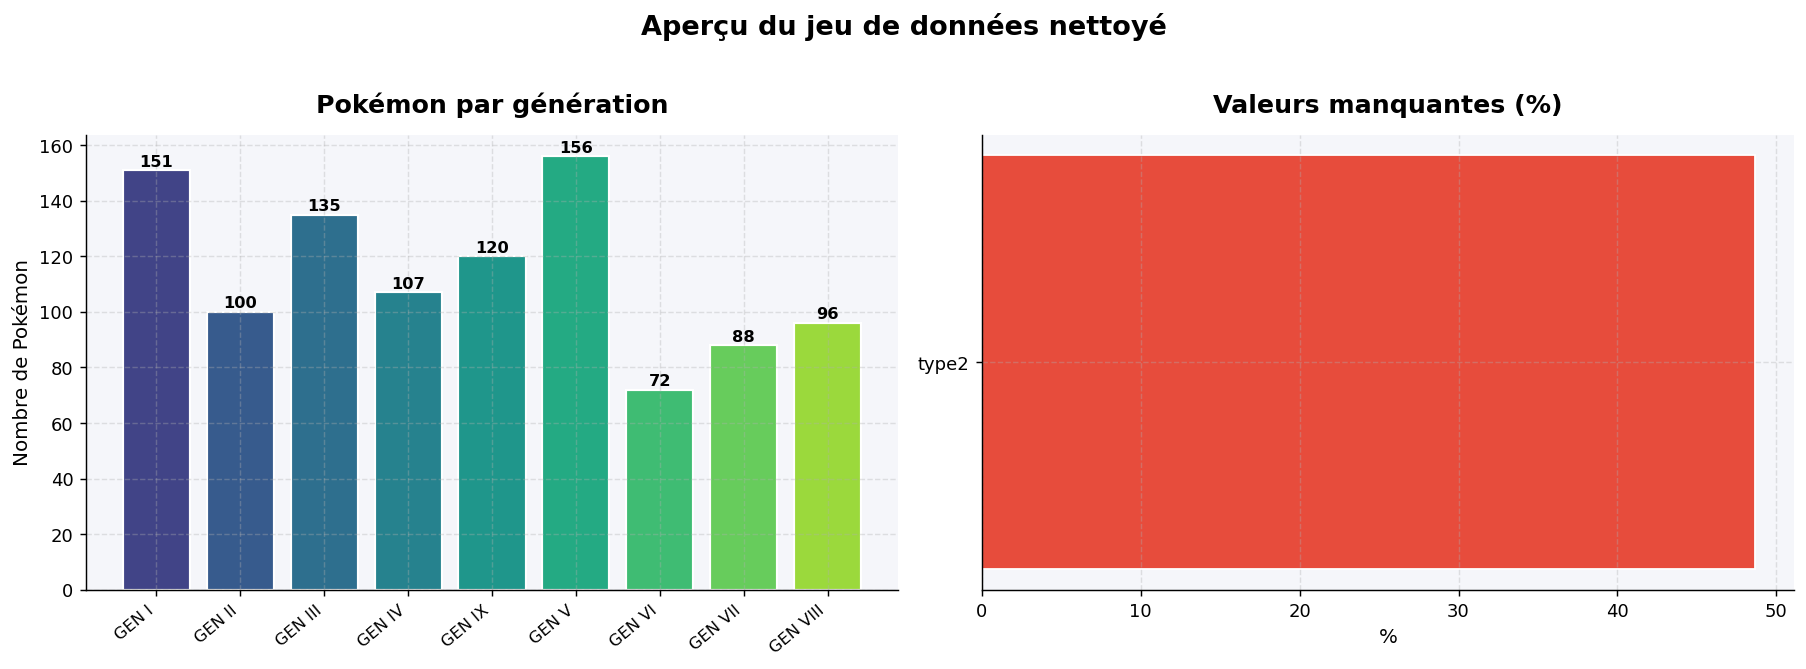


DataFrame final : 1025 Pokémon × 20 colonnes


In [17]:
cols_display = ['id', 'name', 'generation', 'type1', 'type2', 'n_types'] + STATS + ['bst', 'n_moves']
display(df[cols_display].head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gen_counts = df['generation'].value_counts().sort_index()
colors_gen = plt.cm.viridis(np.linspace(0.2, 0.85, len(gen_counts)))
bars = axes[0].bar(range(len(gen_counts)), gen_counts.values, color=colors_gen, edgecolor='white', linewidth=1.2)
axes[0].set_xticks(range(len(gen_counts)))
axes[0].set_xticklabels([g.replace('generation-', 'Gen ').upper() for g in gen_counts.index],
                         rotation=40, ha='right', fontsize=9)
axes[0].set_title('Pokémon par génération', pad=12)
axes[0].set_ylabel('Nombre de Pokémon')
for bar, val in zip(bars, gen_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, str(val),
                 ha='center', fontsize=9, fontweight='bold')

missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
missing = missing[missing > 0]
if len(missing) == 0:
    axes[1].text(0.5, 0.5, 'Aucune valeur manquante !', ha='center', va='center',
                 fontsize=14, color='green', transform=axes[1].transAxes)
    axes[1].set_title('Valeurs manquantes (%)', pad=12)
else:
    axes[1].barh(missing.index, missing.values, color='#E74C3C', edgecolor='white')
    axes[1].set_title('Valeurs manquantes (%)', pad=12)
    axes[1].set_xlabel('%')

plt.suptitle('Aperçu du jeu de données nettoyé', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\nDataFrame final : {df.shape[0]} Pokémon × {df.shape[1]} colonnes')

## 5. Sauvegarde


In [18]:
with open('../data/pokemon_processed.pkl', 'wb') as f:
    pickle.dump(df, f)
print('Données sauvegardées → ../data/pokemon_processed.pkl')

Données sauvegardées → ../data/pokemon_processed.pkl
